<a href="https://colab.research.google.com/github/quirogaez/capstone/blob/main/notebooks/07_EDA_CL%C3%9ASTERESV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **02_EDA – Procesamiento Final de Imágenes**

## Importación y cargue de imágenes

Importar librerías

In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import seaborn as sns
from glob import glob
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import defaultdict

import shutil
import joblib
import tensorflow as tf
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Llamar los archivos

In [ ]:
# #Imagenes sin segmentar
# img_vali = '/content/drive/MyDrive/Capstone/data/pre_procesamiento/redimensionadas/redi_vali'
# img_train = '/content/drive/MyDrive/Capstone/data/pre_procesamiento/redimensionadas/redi_train'
# img_test = '/content/drive/MyDrive/Capstone/data/pre_procesamiento/redimensionadas/redi_test'

#Imagenes segmentadas
img_vali = '/content/drive/MyDrive/Capstone/data/chest_xray_masks_V2_redimensionado/val'
img_train = '/content/drive/MyDrive/Capstone/data/chest_xray_masks_V2_redimensionado/train'
img_test = '/content/drive/MyDrive/Capstone/data/chest_xray_masks_V2_redimensionado/test'

# Ver archivos en la carpeta
df_vali = os.listdir(img_vali)
df_train = os.listdir(img_train)
df_test = os.listdir(img_test)

Función para revisión de cargue de imágenes

In [ ]:
def revisar_carpeta(base_dir):
    info = {}
    total_imagenes = 0
    tamaños = defaultdict(int)

    print(f"\nRevisando: {base_dir}")
    clases = os.listdir(base_dir)
    print(f"Clases encontradas: {clases}")

    for clase in clases:
        ruta_clase = os.path.join(base_dir, clase)
        archivos = os.listdir(ruta_clase)
        total = len(archivos)
        total_imagenes += total
        info[clase] = total

        # Revisar tamaños de las primeras 5 imágenes
        for archivo in archivos[:5]:
            ruta_img = os.path.join(ruta_clase, archivo)
            img = cv2.imread(ruta_img)
            if img is not None:
                tamaños[img.shape[:2]] += 1  # Alto x Ancho

    print(f"Total imágenes: {total_imagenes}")
    print("Distribución por clase:")
    for clase, cantidad in info.items():
        print(f"  - {clase}: {cantidad} imágenes")

    print("Tamaños detectados (muestra):")
    for tamaño, cuenta in tamaños.items():
        print(f"  - {tamaño}: {cuenta} ejemplo(s)")

Aplicar función `revisar_carpeta` a cada conjunto de datos

In [ ]:
# Conjunto de entrenamiento
revisar_carpeta(img_train)

# Conjunto de valdiación
revisar_carpeta(img_vali)

# Conjunto de testeo
revisar_carpeta(img_test)


Revisando: /content/drive/MyDrive/Capstone/data/chest_xray_masks_V2_redimensionado/train
Clases encontradas: ['PNEUMONIA', 'NORMAL']
Total imágenes: 5132
Distribución por clase:
  - PNEUMONIA: 3875 imágenes
  - NORMAL: 1257 imágenes
Tamaños detectados (muestra):
  - (224, 224): 10 ejemplo(s)

Revisando: /content/drive/MyDrive/Capstone/data/chest_xray_masks_V2_redimensionado/val
Clases encontradas: ['PNEUMONIA', 'NORMAL']
Total imágenes: 16
Distribución por clase:
  - PNEUMONIA: 8 imágenes
  - NORMAL: 8 imágenes
Tamaños detectados (muestra):
  - (224, 224): 10 ejemplo(s)

Revisando: /content/drive/MyDrive/Capstone/data/chest_xray_masks_V2_redimensionado/test
Clases encontradas: ['PNEUMONIA', 'NORMAL']
Total imágenes: 624
Distribución por clase:
  - PNEUMONIA: 390 imágenes
  - NORMAL: 234 imágenes
Tamaños detectados (muestra):
  - (224, 224): 10 ejemplo(s)


Cargar datasets

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    img_train, # Entrenamiento
    batch_size = 32,
    label_mode = 'categorical'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    img_test, # Testeo
    batch_size = 32,
    label_mode = 'categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    img_vali, # Validación
    batch_size = 32,
    label_mode = 'categorical'
)

Found 5132 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


## Procesamiento final de imágenes

### Normalización

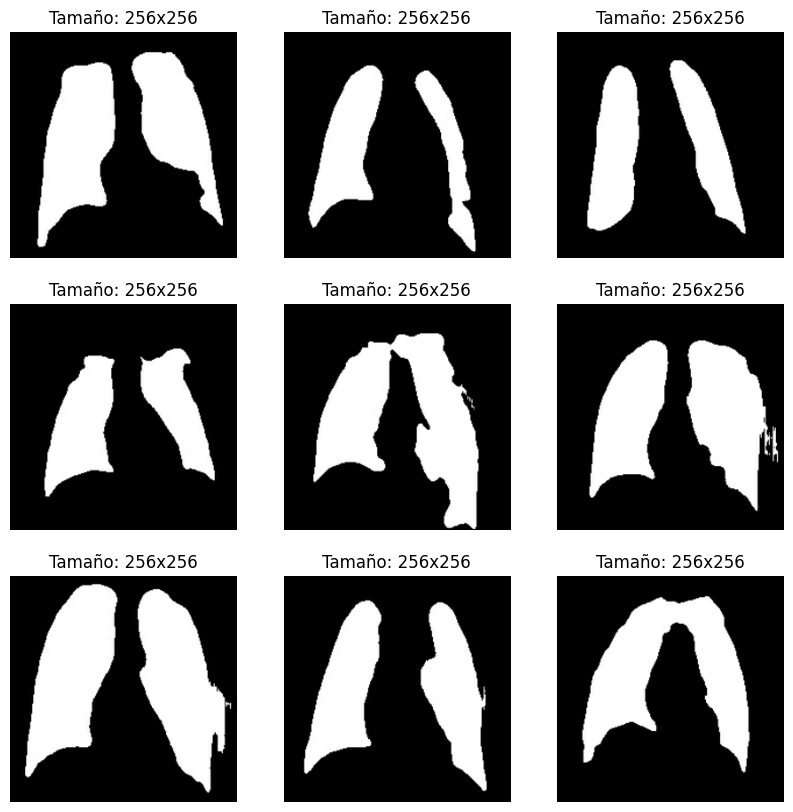

In [ ]:
# Mostrar una muestra de imágenes redimensionadas
def mostrar_imagenes(dataset, num_imagenes=9):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):  # Toma solo un batch
        for i in range(num_imagenes):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.axis("off")
            plt.title(f"Tamaño: {images[i].shape[0]}x{images[i].shape[1]}")
mostrar_imagenes(train_ds)  # o val_ds, test_ds

In [ ]:
normalizar = lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(normalizar).prefetch(AUTOTUNE)
val_ds = val_ds.map(normalizar).prefetch(AUTOTUNE)
test_ds = test_ds.map(normalizar).prefetch(AUTOTUNE)

## Aplicación de clusterización para diferenciar la neumonía viral y bacteriana

### *Flatten* o extracción de características

In [ ]:
# Extraer datos del dataset completo
class_names = ['NORMAL', 'PNEUMONIA']

def dataset_to_numpy(dataset):
    images_list = []
    labels_list = []
    for batch in dataset:
        images, labels = batch
        images_list.append(images.numpy())
        labels_list.append(labels.numpy())
    images_np = np.concatenate(images_list, axis=0)
    labels_np = np.concatenate(labels_list, axis=0)
    return images_np, labels_np

# Convertir los datos a vector
X_train, y_train = dataset_to_numpy(train_ds)

# Identificar índice de la clase "PNEUMONIA"
print("Clases:", class_names)  # ['NORMAL', 'PNEUMONIA']
indice_pneumonia = class_names.index('PNEUMONIA')

Clases: ['NORMAL', 'PNEUMONIA']


Filtrar solo las imágenes con 'PNEUMONIA'

In [ ]:
mascara_pneumonia = np.argmax(y_train, axis = 1) == indice_pneumonia
X_pneumonia = X_train[mascara_pneumonia]

print("Cantidad de imágenes con neumonía:", X_pneumonia.shape[0])

Cantidad de imágenes con neumonía: 3875


Flatten

In [ ]:
X_pneumonia_flat = X_pneumonia.reshape(X_pneumonia.shape[0], -1)

print("Forma original:", X_pneumonia[0].shape)
print("Forma aplanada:", X_pneumonia_flat[0].shape)

Forma original: (256, 256, 3)
Forma aplanada: (196608,)


### Reducción de dimensionalidad

Iterar cantidad de componententes para dos clústeres (dos tipos de neumonía: viral y bacteriana)

In [ ]:
sil_aggl, sil_km = {}, {}

for n_comp in [5, 10, 15]:
    # 1) Reducir dimensionalidad con PCA
    pca = PCA(n_components = n_comp, random_state = 42)
    X_pca = pca.fit_transform(X_pneumonia_flat) # df

    for k in [2]:
        # 2) Clustering
        agg = AgglomerativeClustering(n_clusters = k, linkage = 'ward')
        labels_agg = agg.fit_predict(X_pca)
        sil_aggl[(n_comp, k)] = silhouette_score(X_pca, labels_agg)

        km = KMeans(n_clusters = k, random_state = 42)
        labels_km = km.fit_predict(X_pca)
        sil_km[(n_comp, k)] = silhouette_score(X_pca, labels_km)

# Mostrar resultados
print("n_comp k   Silhouette Agglo   Silhouette KMeans")
for (n_comp, k), score in sil_aggl.items():
    print(f"{n_comp:>6} {k:>2}   {score:.4f}             {sil_km[(n_comp,k)]:.4f}")

n_comp k   Silhouette Agglo   Silhouette KMeans
     5  2   0.1727             0.2097
    10  2   0.1229             0.1607
    15  2   0.1175             0.1449


In [ ]:
sil_aggl, sil_km = {}, {}

for n_comp in [20, 50, 100]:
    # 1) Reducir dimensionalidad con PCA
    pca = PCA(n_components = n_comp, random_state = 42)
    X_pca = pca.fit_transform(X_pneumonia_flat) # df

    for k in [2]:
        # 2) Clustering
        agg = AgglomerativeClustering(n_clusters = k, linkage = 'ward')
        labels_agg = agg.fit_predict(X_pca)
        sil_aggl[(n_comp, k)] = silhouette_score(X_pca, labels_agg)

        km = KMeans(n_clusters = k, random_state = 42)
        labels_km = km.fit_predict(X_pca)
        sil_km[(n_comp, k)] = silhouette_score(X_pca, labels_km)

# Mostrar resultados
print("n_comp k   Silhouette Agglo   Silhouette KMeans")
for (n_comp, k), score in sil_aggl.items():
    print(f"{n_comp:>6} {k:>2}   {score:.4f}             {sil_km[(n_comp,k)]:.4f}")

n_comp k   Silhouette Agglo   Silhouette KMeans
    20  2   0.1060             0.1357
    50  2   0.0778             0.1142
   100  2   0.1174             0.1037


In [ ]:
sil_aggl, sil_km = {}, {}

for n_comp in [150, 200, 250]:
    # 1) Reducir dimensionalidad con PCA
    pca = PCA(n_components = n_comp, random_state = 42)
    X_pca = pca.fit_transform(X_pneumonia_flat) # df

    for k in [2]:
        # 2) Clustering
        agg = AgglomerativeClustering(n_clusters = k, linkage = 'ward')
        labels_agg = agg.fit_predict(X_pca)
        sil_aggl[(n_comp, k)] = silhouette_score(X_pca, labels_agg)

        km = KMeans(n_clusters = k, random_state = 42)
        labels_km = km.fit_predict(X_pca)
        sil_km[(n_comp, k)] = silhouette_score(X_pca, labels_km)

# Mostrar resultados
print("n_comp k   Silhouette Agglo   Silhouette KMeans")
for (n_comp, k), score in sil_aggl.items():
    print(f"{n_comp:>6} {k:>2}   {score:.4f}             {sil_km[(n_comp,k)]:.4f}")

n_comp k   Silhouette Agglo   Silhouette KMeans
   150  2   0.0718             0.0993
   200  2   0.0770             0.0968
   250  2   0.0665             0.0951


Reducir a $n = 5$ dimensiones

In [ ]:
pca = PCA(n_components = 5, random_state = 42)
X_pneumonia_pca = pca.fit_transform(X_pneumonia_flat)

print("Nueva forma tras PCA:", X_pneumonia_pca.shape)

Nueva forma tras PCA: (3875, 5)


Dos clústeres para los tipos de neumonía: viral y bacteriana

In [ ]:
kmeans = KMeans(n_clusters = 2, random_state = 42)
clusters = kmeans.fit_predict(X_pneumonia_pca)

### Visualizar imágenes por clústeres

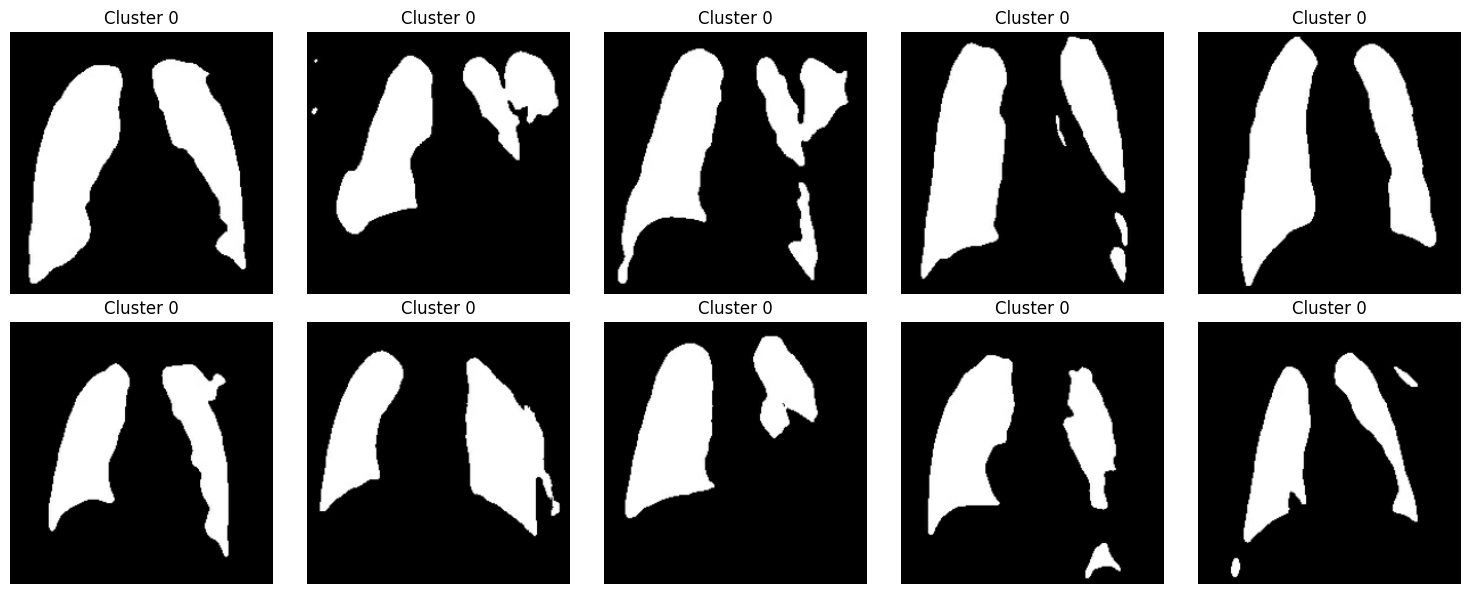

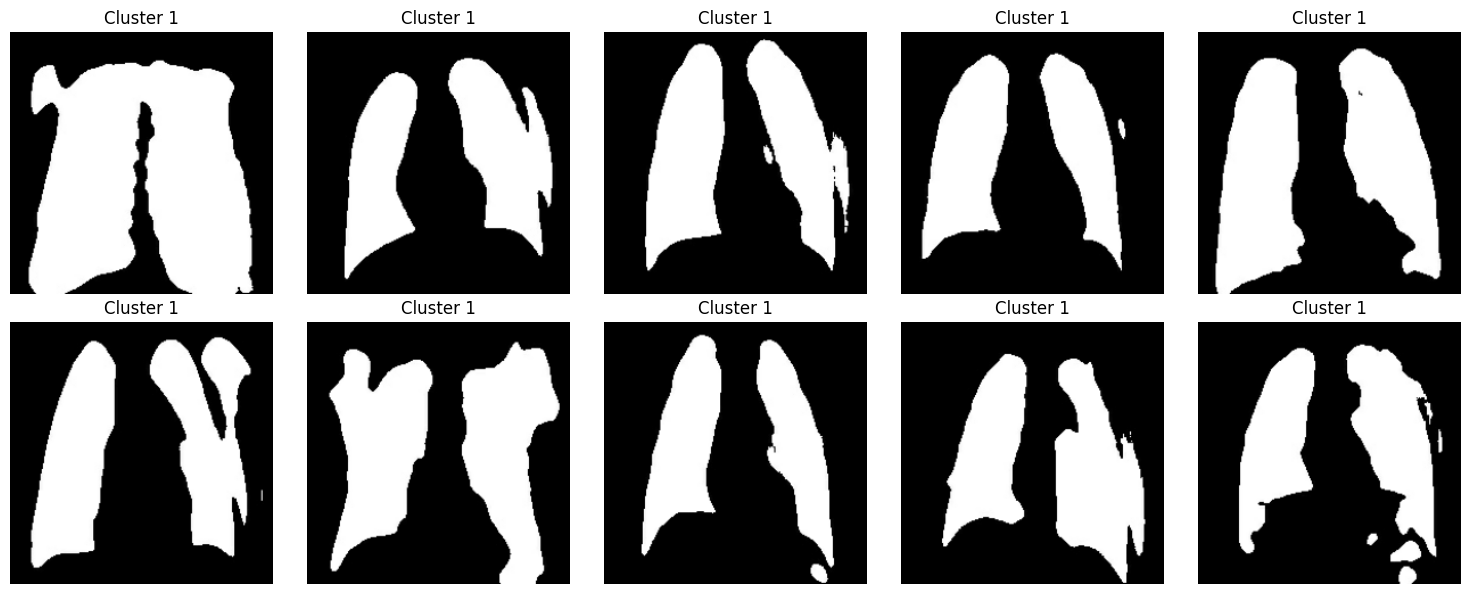

In [ ]:
def mostrar_imagenes_por_cluster(imagenes, cluster_labels, cluster_id, cantidad = 10):
    indices = np.where(cluster_labels == cluster_id)[0]
    seleccionadas = np.random.choice(indices, min(cantidad, len(indices)), replace = False)

    plt.figure(figsize = (15, 6))
    for i, idx in enumerate(seleccionadas):
        plt.subplot(2, 5, i + 1)
        plt.imshow(imagenes[idx])
        plt.title(f"Cluster {cluster_id}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Mostrar imágenes del cluster 0 y 1
mostrar_imagenes_por_cluster(X_pneumonia, clusters, cluster_id = 0)
mostrar_imagenes_por_cluster(X_pneumonia, clusters, cluster_id = 1)

Visualizar clústeres por TSNE

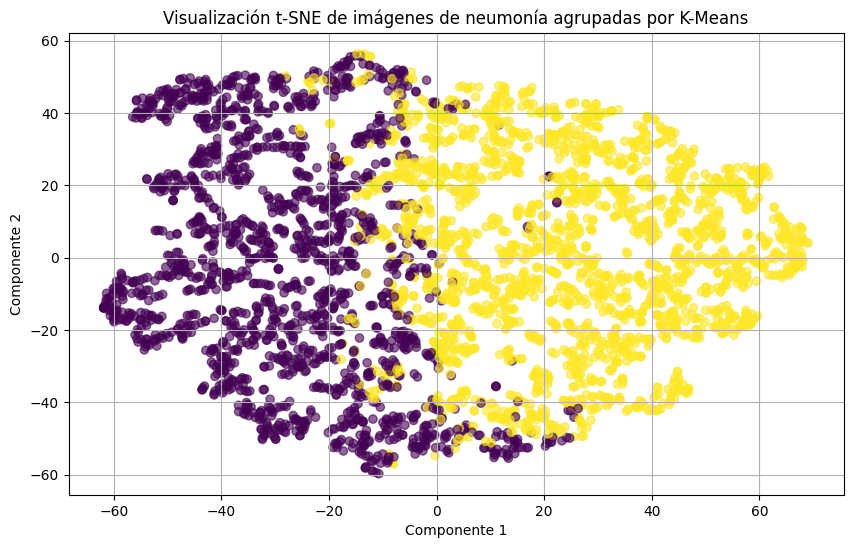

In [ ]:
tsne = TSNE(n_components = 2, random_state = 42, perplexity = 30)
X_pneumonia_2D = tsne.fit_transform(X_pneumonia_pca)

plt.figure(figsize = (10, 6))
plt.scatter(X_pneumonia_2D[:, 0], X_pneumonia_2D[:, 1], c = clusters, cmap='viridis', alpha = 0.6)
plt.title("Visualización t-SNE de imágenes de neumonía agrupadas por K-Means")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

### Evaluación de clústers

#### **Coeficiente de Siluetta:** Varía de -1 a 1, donde el óptimo es 1.

Coeficiente de Silueta Promedio: 0.2097


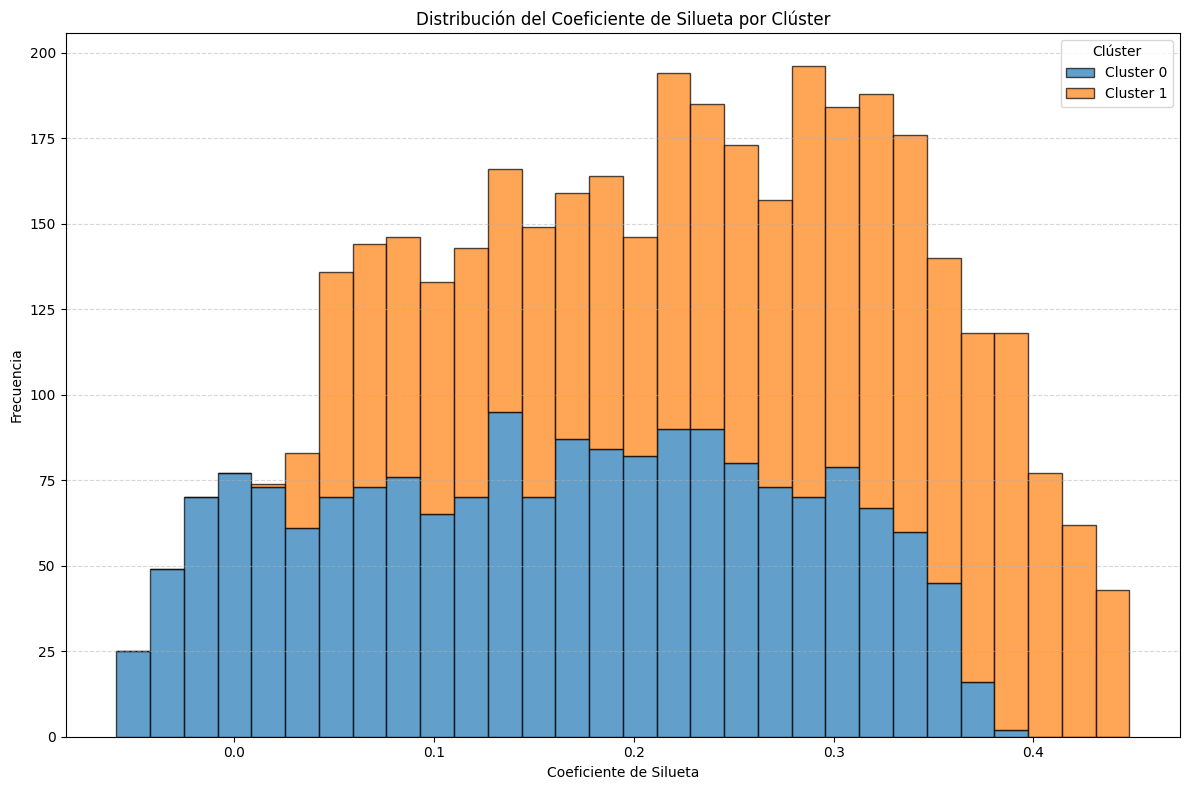

In [ ]:
# Coeficiente de silueta promedio
silhouette_avg = silhouette_score(X_pneumonia_pca, clusters)
print(f"Coeficiente de Silueta Promedio: {silhouette_avg:.4f}")

# Coeficientes individuales de silueta
silhouette_vals = silhouette_samples(X_pneumonia_pca, clusters)

# Df para inspección
df_sil = pd.DataFrame({
    "Silhouette": silhouette_vals,
    "Cluster": clusters
})

## Histograma
plt.figure(figsize = (12, 8))
cluster_ids = np.unique(clusters)
data_by_cluster = [df_sil[df_sil["Cluster"] == cid]["Silhouette"].values
                   for cid in cluster_ids]

plt.hist(
    data_by_cluster,
    bins = 30,
    stacked = True,
    label=[f"Cluster {cid}" for cid in cluster_ids],
    alpha = 0.7,
    edgecolor = 'black'
)

plt.title("Distribución del Coeficiente de Silueta por Clúster")
plt.xlabel("Coeficiente de Silueta")
plt.ylabel("Frecuencia")
plt.legend(title = "Clúster")
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

Sugiere que existe una estructura de clusters, superando claramente la aleatoriedad. Con separaciones débiles y algunos puntos cerca a los límites.

#### **Índice de Davies–Bouldin:** Varía de 0 a $∞$, donde el óptimo es 0.

In [ ]:
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(X_pneumonia_pca, clusters)
print(f"Davies-Bouldin Score: {db_score:.4f}")

Davies-Bouldin Score: 1.7839


Refleja que cada cluster está lejano de los demás en relación con su propio “tamaño” (menor solapamiento y mayor separación), muestra una separación moderada.

### Cantidad de imágenes por clúster

In [ ]:
# Crear DataFrame con las componentes principales y los clústeres
df_pca = pd.DataFrame(X_pneumonia_pca, columns=[f'PC{i+1}' for i in range(X_pneumonia_pca.shape[1])])
df_pca['Cluster'] = clusters

In [ ]:
# Recuentos ordenada por índice de clúster
cluster_counts = df_pca['Cluster'].value_counts().sort_index()
counts_df = cluster_counts.reset_index()
counts_df.columns = ['Cluster', 'Recuento']; counts_df

,Cluster,Recuento
0,0,1799
1,1,2076


Visualizar con imágenes de la clase 'NORMAL'

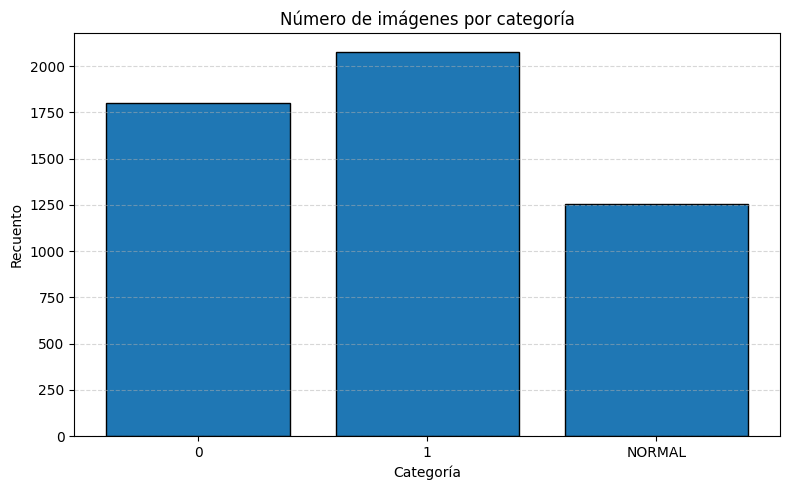

In [ ]:
# Recuento de normales
idx_normal = class_names.index('NORMAL')
normal_count = np.sum(np.argmax(y_train, axis = 1) == idx_normal)

# Partir del DataFrame de clústeres original
counts_df_plot = counts_df.copy()
counts_df_plot['Cluster'] = counts_df_plot['Cluster'].astype(str)

# DataFrame con la fila NORMAL y concatenar
normal_row = pd.DataFrame({
    'Cluster': ['NORMAL'],
    'Recuento': [normal_count]
})

counts_df_plot = pd.concat([counts_df_plot, normal_row], ignore_index=True)

# Visualizar
plt.figure(figsize = (8,5))
plt.bar(
    counts_df_plot['Cluster'],
    counts_df_plot['Recuento'],
    edgecolor = 'black'
)
plt.title("Número de imágenes por categoría")
plt.xlabel("Categoría")
plt.ylabel("Recuento")
plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

## Codificación de clases: Normal, Neumonía Viral y Neumonía Bacterial

En este modelo de clustering, se asigna la **neumonía bacteriana** al ***Cluster 0*** porque suele presentar una única zona blanca, densa y bien definida (consolidación), que aparece localizada en una parte del pulmón. Por otra parte, la **neumonía viral se asigna** al ***Cluster 1***, ya que generalmente muestra un patrón más difuso y bilateral, con áreas blancas más suaves y dispersas, parecidas a una niebla, lo que indica una afectación más extendida del tejido pulmonar. Estas diferencias visuales permiten separar los casos en dos grupos distintos sin necesidad de etiquetas clínicas.


Asignar etiquetas al conjunto de entrenamiento

In [ ]:
# DataFrame para imágenes de neumonía con etiquetas nuevas
df_pneumonia = pd.DataFrame({
    "Cluster": clusters
})

# Asignar etiquetas
df_pneumonia["Label"] = df_pneumonia["Cluster"].map({
    0: "PNEUMONIA-VIRAL",
    1: "PNEUMONIA-BACTERIAL"
})

In [ ]:
# Etiquetas originales del dataset de entrenamiento
labels_originales = np.argmax(y_train, axis = 1)

# Inicializar lista para nuevas etiquetas
nuevas_etiquetas = []

# Reasignar etiquetas
indice_actual = 0  # Para recorrer df_pneumonia

for idx in range(len(labels_originales)):
    if labels_originales[idx] == indice_pneumonia:
        # Imagen con neumonía: usar etiqueta desde clustering
        nueva = df_pneumonia.iloc[indice_actual]["Label"]
        nuevas_etiquetas.append(nueva)
        indice_actual += 1
    else:
        # Imagen normal
        nuevas_etiquetas.append("NORMAL")

In [ ]:
df_final = pd.DataFrame({
    "Label": nuevas_etiquetas
})

# Ver conteo por clase
print(df_final["Label"].value_counts())

Label
PNEUMONIA-BACTERIAL    2076
PNEUMONIA-VIRAL        1799
NORMAL                 1257
Name: count, dtype: int64


Visualizar imágenes etiquetadas

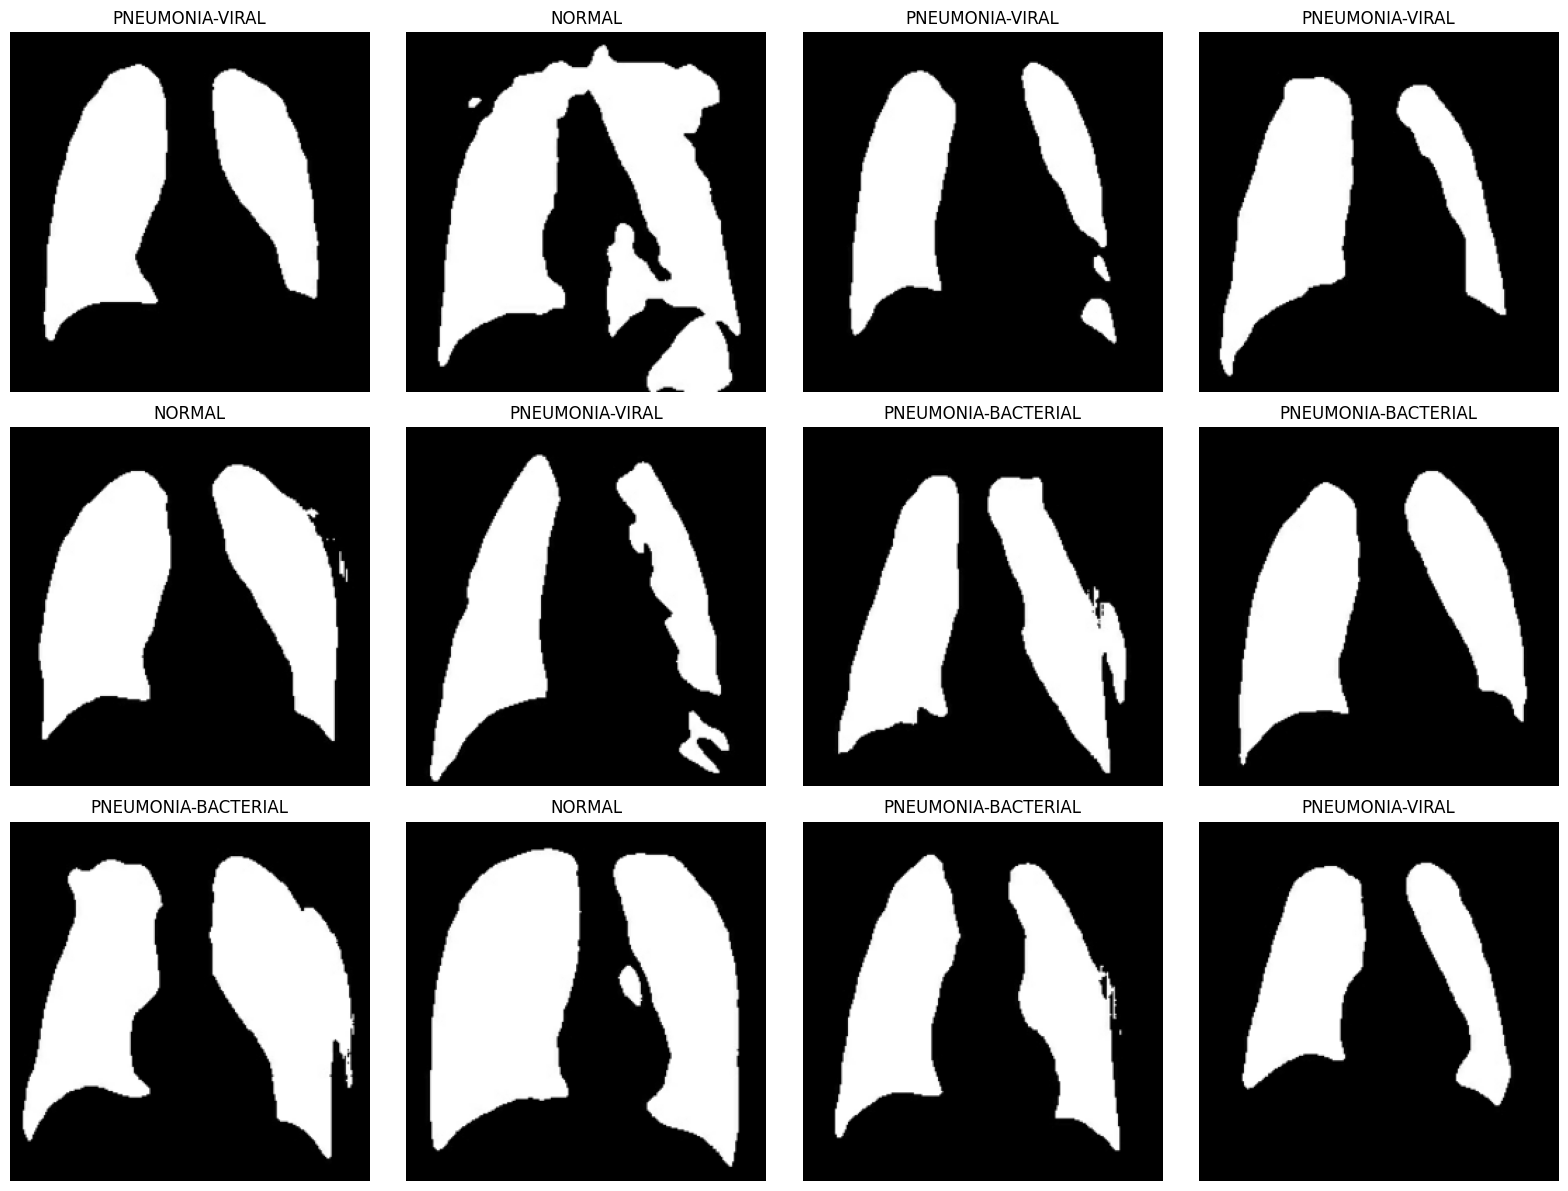

In [ ]:
def imagenes_etiquetas(imagenes, etiquetas, cantidad = 12):
    seleccionados = np.random.choice(len(imagenes), cantidad, replace = False)

    filas = cantidad // 4 + (cantidad % 4 != 0)
    plt.figure(figsize = (16, 4 * filas))

    for i, idx in enumerate(seleccionados):
        plt.subplot(filas, 4, i + 1)
        plt.imshow(imagenes[idx])
        plt.title(f"{etiquetas[idx]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Aplicar función
imagenes_etiquetas(X_train, nuevas_etiquetas)

### Guardar el modelo y exportación de nuevas imágenes

Exportar imágenes con las nuevas etiquetas

In [ ]:
# Ruta donde están las imágenes originales segmentadas
base_dir = img_train

# Nueva ruta donde se guardarán las imágenes clasificadas
output_dir = '/content/drive/MyDrive/Capstone/data/multiclass/V2/train'

# Verificar de que las carpetas destino existan
os.makedirs(f'{output_dir}/PNEUMONIA-BACTERIAL', exist_ok = True)
os.makedirs(f'{output_dir}/PNEUMONIA-VIRAL', exist_ok = True)
os.makedirs(f'{output_dir}/NORMAL', exist_ok = True)

# Obtener nombres de archivos por clase
pneumonia_files = os.listdir(os.path.join(base_dir, 'PNEUMONIA'))
normal_files = os.listdir(os.path.join(base_dir, 'NORMAL'))

# Recorrer los archivos de neumonía
indice_actual = 0

for i, label in enumerate(nuevas_etiquetas):
    if label == 'NORMAL':
        # Imagen NORMAL
        filename = normal_files.pop(0)  # Saca la siguiente imagen NORMAL
        src_path = os.path.join(base_dir, 'NORMAL', filename)
        dst_path = os.path.join(output_dir, 'NORMAL', filename)
    else:
        # Imagen con neumonía (se revisa la etiqueta asignada)
        filename = pneumonia_files[indice_actual]
        src_path = os.path.join(base_dir, 'PNEUMONIA', filename)

        if label == 'PNEUMONIA-BACTERIAL':
            dst_path = os.path.join(output_dir, 'PNEUMONIA-BACTERIAL', filename)
        else:
            dst_path = os.path.join(output_dir, 'PNEUMONIA-VIRAL', filename)

        indice_actual += 1

    # Copiar imagen al nuevo destino
    shutil.copy(src_path, dst_path)

print('Imágenes exportadas y clasificadas exitosamente.')

Imágenes exportadas y clasificadas exitosamente.


Guardar el modelo para la evaluación con el conjunto de validación y testeo

In [ ]:
# Crear carpeta
modelo_dir = '/content/drive/MyDrive/Capstone/modelos'
os.makedirs(modelo_dir, exist_ok = True)

# Guardar modelos
joblib.dump(pca, os.path.join(modelo_dir, 'pca_pneumonia_V3.pkl'))
joblib.dump(kmeans, os.path.join(modelo_dir, 'kmeans_pneumonia_V3.pkl'))

# Confirmar que los modelos están guardados
print('Modelos guardados en:', modelo_dir)
print(os.listdir(modelo_dir))

Modelos guardados en: /content/drive/MyDrive/Capstone/modelos
['pca_pneumonia_V3.pkl', 'kmeans_pneumonia_V3.pkl']
